# Final Exam (part 2) - Computational Physics 2

### Deadline: Friday 6 June 2025 (by 23h59)
### Credits: 10 points

### Please keep the structure provided below and submit an organised notebook with clear answers to each item.


## 2. FFT method for fluid dynamics: 1D Shock waves

We wish to study the emergence of 1D shock waves in fluids. To do this we will modify our one-way wave equation to account for non-linear convection, i.e. we will consider that the speed of an initial Gaussian density perturbation $\rho(x, 0) = 4\,e^{-x^2}$ propagating across a periodic 1D domain is not constant, but a function of the density itself, so that our PDE becomes:

$$\frac{\partial \rho}{\partial t} + \rho\frac{\partial \rho}{\partial x} =0$$


As we see from the above equation, portions of $\rho$ with larger amplitudes will convect more rapidly, giving rise to wave steepening (i.e. to a discontinuity, which we call a **shock wave**). Without a diffusive term, the shock would become infinitely steep. Therefore, we add a diffusive (parabolic) term to our PDE so that the shock maintains a finite width. Our PDE then becomes:

$$\frac{\partial \rho}{\partial t} + \rho\frac{\partial \rho}{\partial x} =\alpha\frac{\partial^2 \rho}{\partial x^2}$$

where $\alpha$ is a diffusion constant.

Implement the following tasks using **python classes**:

**(a)** Create an appropriate domain and a reasonable time vector for the problem, and make a plot of the initial density profile.



In [55]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [80]:
class DensityEvolution:
    def __init__(self, lx=10, lt=50.0, dx=0.1, dt=0.01):

        self.lx = lx
        self.lt = lt
        self.dx = dx
        self.dt = dt
        self.x = np.arange(-lx/2, lx/2, dx)
        self.t = np.arange(0, lt, dt)
        self.k = 2 * np.pi * np.fft.fftfreq(len(self.x), d=dx)
        self.rho_0 = 4 * np.exp(-self.x**2)
        self.rho_0_hat = np.fft.fft(self.rho_0)
        self.ampli_rho_0_hat = np.abs(self.rho_0_hat) / (self.rho_0_hat.size // 2)

    def plot_initial_density(self, space):

        if space == "real":
            plt.figure(figsize=(10, 5))
            plt.plot(self.x, self.rho_0, label='Initial density profile')
            plt.title('Initial Density Profile')
            plt.xlabel('x')
            plt.ylabel('Density')
            plt.grid()
            plt.legend()
            plt.show()
        elif space == "fourier":
            plt.figure(figsize=(10, 5))
            plt.stem(self.k, self.ampli_rho_0_hat, 'b', markerfmt=" ", basefmt="-b")
            plt.title('Initial Density Profile in Fourier Space')
            plt.xlabel('k')
            plt.ylabel('Amplitude')
            plt.grid()
            plt.show()
        else:
            raise ValueError("Invalid space. Choose 'real' or 'fourier'.")



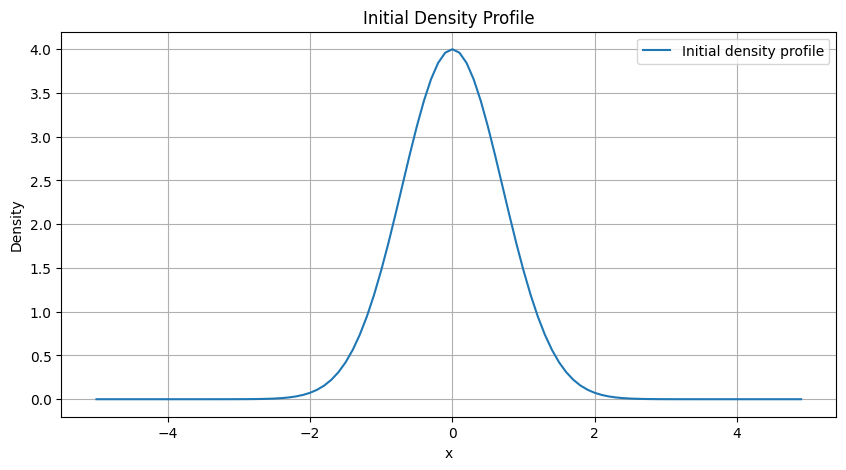

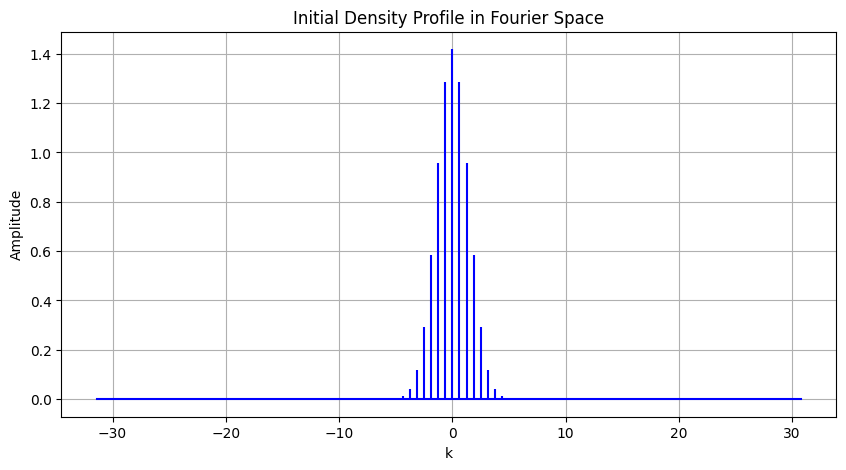

In [81]:
density_evolution = DensityEvolution()
density_evolution.plot_initial_density("real")
density_evolution.plot_initial_density("fourier")


**(b)** Write a method for the right-hand-side (RHS) of the PDE that allows you to map in and out of the Fourier domain at each time. Note that this PDE is non-linear, so the function should return the RHS in real space. **Hint:** it may be helpful to write the derivative terms in our PDE in Fourier domain.



In [82]:
# child class for the ODE system
class DensityODE(DensityEvolution):
    def __init__(self, lx=10, lt=5.0, dx=0.1, dt=0.01):
        super().__init__(lx, lt, dx, dt)  
        self.rho_0_conc = np.concatenate((self.rho_0_hat.real, self.rho_0_hat.imag))      

    def rhs_ode(self, t, rho, alpha):
        # separate real and imaginary parts
        n = len(self.k)
        rho_hat_real = rho[:n]  
        rho_hat_imag = rho[n:]  
        
        # reconstruct complex Fourier coefficients
        rho_hat = rho_hat_real + 1j * rho_hat_imag
        
        # back to real space
        rho_real = np.fft.ifft(rho_hat)
        
        # spatial derivative in k space
        drho_dx_hat = 1j * self.k * rho_hat
        
        # back to real space
        drho_dx = np.fft.ifft(drho_dx_hat)
        
        # non-linear term in real space
        nonlinear_term = rho_real * drho_dx 
        
        # transform non-linear term to k space
        nonlinear_term_hat = np.fft.fft(nonlinear_term)
        
        # diffusion term in fourier
        diffusion_term_hat = -alpha * self.k**2 * rho_hat  
        
        # compute total RHS in Fourier space
        rhs_hat = -nonlinear_term_hat + diffusion_term_hat
        
        # separate real and imaginary parts for output
        rhs_conc = np.concatenate((rhs_hat.real, rhs_hat.imag))
        
        return rhs_conc

    def solve_ode(self, alpha):
        # Solve


        solution = solve_ivp(
            self.rhs_ode,
            t_span=[0, self.lt],
            y0=self.rho_0_conc,
            method='RK45',
            t_eval=self.t,
            args=(alpha,),
            rtol=1e-5,
            atol=1e-8
        )

        t_solution = solution.t
        rho_solution = solution.y

        # get the density in real space
        n = len(self.x)
        density = np.zeros((len(t_solution), n))

        for i, t in enumerate(t_solution):
            rho_hat_real = rho_solution[:n, i]
            rho_hat_imag = rho_solution[n:, i]
            
            rho_hat = rho_hat_real + 1j * rho_hat_imag
            density[i] = np.real(np.fft.ifft(rho_hat))
        
        return t_solution, density


**(c)** Choose a reasonable value for the diffusion constant, $\alpha$, and call your function in (b). What is this function achieving so far and what space (real or Fourier) is the output in?



In [83]:
alpha = 0.1
density_ode = DensityODE()
print(density_ode.rhs_ode(0, density_ode.rho_0_conc, alpha))

[ 8.07846194e-15  2.53589646e+00 -7.54400672e+00  1.03626027e+01
 -9.23218057e+00  5.93411544e+00 -2.88551850e+00  1.08867068e+00
 -3.23543896e-01  7.64829717e-02 -1.44770450e-02  2.20464817e-03
 -2.71058613e-04  2.69784933e-05 -2.17751847e-06  1.43491011e-07
 -6.96489103e-09  1.03953570e-09  7.42516279e-10  7.99541847e-10
  8.43084514e-10  8.86196767e-10  9.28465946e-10  9.70227103e-10
  1.01156717e-09  1.05264065e-09  1.09380675e-09  1.13491636e-09
  1.17657561e-09  1.21853492e-09  1.26114744e-09  1.30460338e-09
  1.34913225e-09  1.39459571e-09  1.44170369e-09  1.49002968e-09
  1.54016725e-09  1.59208773e-09  1.64641372e-09  1.70275456e-09
  1.76139310e-09  1.82303482e-09  1.88745836e-09  1.95515820e-09
  2.02619962e-09  2.10118010e-09  2.18018773e-09  2.26348451e-09
  2.35167806e-09  2.44491494e-09  2.54387828e-09  2.44505186e-09
  2.35165053e-09  2.26356696e-09  2.18017670e-09  2.10112800e-09
  2.02622219e-09  1.95518152e-09  1.88724896e-09  1.82309512e-09
  1.76132594e-09  1.70267

Its achieving to compute the RHS in fourier space, and the output is in fourier space as well.


**(d)** Find and plot the solution, $\rho(x,t)$, **using your FFT method**. For this, you need to feed a scipy ODE integrator with the function you created in (b). **Hint:** make sure you feed the correct wavenumbers to the ODE integrator.



In [84]:
t0, d0 = density_ode.solve_ode(alpha=alpha)

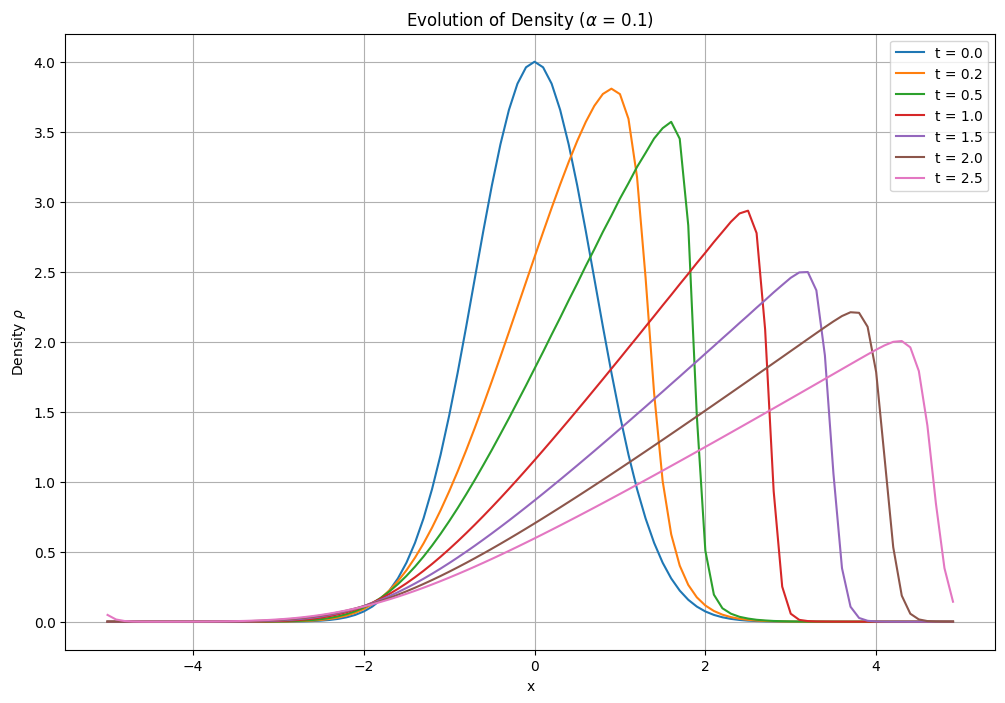

In [88]:
# solution at different times
plt.figure(figsize=(12, 8))
times_to_plot = [0, 25, 50, 100, 150, 200, 250]

x = density_ode.x  

for idx in times_to_plot:
    if idx < len(t0):
        plt.plot(x, d0[idx], label=f't = {t0[idx]:.1f}')

plt.title(fr'Evolution of Density ($\alpha$ = {alpha})')
plt.xlabel('x')
plt.ylabel(r'Density $\rho$')
plt.legend()
plt.grid(True)
plt.show()



**(e)** Repeat the above calculations for two additional $\alpha$ values (one of them should be 0). Then, make a figure (or movie) with three panels comparing the results for different $\alpha$ values and briefly discuss the role of this parameter in regulating the morphology of the shock wave.

In [89]:
alpha1 = 0.0
alpha2 = 10.0
density_ode1 = DensityODE()
density_ode2 = DensityODE()
t1, d1 = density_ode1.solve_ode(alpha=alpha1)
t2, d2 = density_ode2.solve_ode(alpha=alpha2)


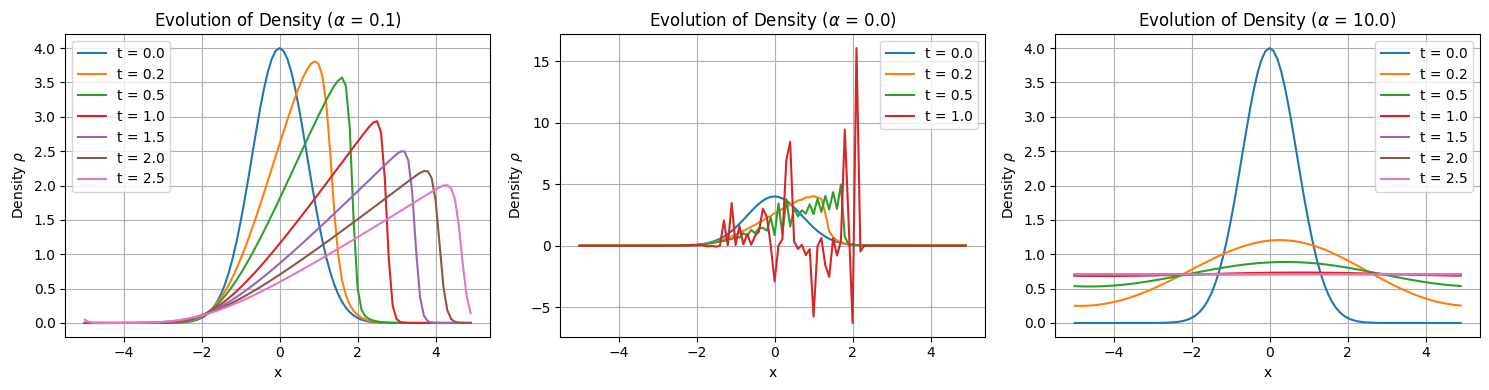

In [90]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))


for idx in times_to_plot:
    if idx < len(t0):
        ax1.plot(x, d0[idx], label=f't = {t0[idx]:.1f}')
ax1.set_title(fr'Evolution of Density ($\alpha$ = {alpha})')
ax1.set_xlabel('x')
ax1.set_ylabel(r'Density $\rho$')
ax1.legend()
ax1.grid(True)


for idx in times_to_plot:
    if idx < len(t1):
        ax2.plot(x, d1[idx], label=f't = {t1[idx]:.1f}')
ax2.set_title(fr'Evolution of Density ($\alpha$ = {alpha1})')
ax2.set_xlabel('x')
ax2.set_ylabel(r'Density $\rho$')
ax2.legend()
ax2.grid(True)


for idx in times_to_plot:
    if idx < len(t2):
        ax3.plot(x, d2[idx], label=f't = {t2[idx]:.1f}')
ax3.set_title(fr'Evolution of Density ($\alpha$ = {alpha2})')
ax3.set_xlabel('x')
ax3.set_ylabel(r'Density $\rho$')
ax3.legend()
ax3.grid(True)

plt.tight_layout()
plt.show()